In [1]:
import scanpy as sc
import numpy as np
import pandas as pd

In [2]:
# ------------- simulate -------------
N, G, M = 1000, 3000, 50
np.random.seed(42)
adata = sc.AnnData(
    X=np.random.negative_binomial(n=1, p=0.2, size=(N, G)).astype('float32')
)
module_genes = np.random.choice(G, M, replace=False)
z = np.random.normal(0, 1, size=N)

for idx, g in enumerate(module_genes):
    w = np.random.uniform(0.8, 1.2)
    adata.X[:, g] *= np.exp(w * z)          # multiplicative on linear scale

# ------------- fake DEA -------------
adata.obs['group'] = np.random.choice(['A', 'B'], size=N)
sc.tl.rank_genes_groups(adata, groupby='group', method='wilcoxon')

# ------------- CNA -------------
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000, subset=True)
sc.tl.pca(adata)
sc.pp.neighbors(adata, n_neighbors=20, n_pcs=30)
# Pearson gene-gene correlation
corr = np.corrcoef(adata.X.T)
# Simple module detection: cluster correlation matrix
from scipy.cluster.hierarchy import linkage, fcluster
Z = linkage(1 - corr, method='average')
clusters = fcluster(Z, t=0.85, criterion='distance')

/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_1992014/3978216167.py:28: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(1 - corr, method='average')


In [3]:
from __future__ import annotations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [5]:

def run_simulation(
    n_cells: int = 1_000,
    n_genes: int = 3_000,
    module_size: int = 50,
    negbin_n: int = 1,
    negbin_p: float = 0.2,
    random_state: int = 42,
    k_clusters: int = 2,
    logfc_threshold: float = 0.5,
    show_plot: bool = True,
) -> pd.DataFrame:
    """
    Return a per-gene table with |logFC|, kME and module-membership.
    Optionally show a scatter-plot.
    """
    rng = np.random.default_rng(random_state)

    # ------------------------------------------------------------------
    # 1) Simulate baseline counts and add a latent correlated programme
    # ------------------------------------------------------------------
    counts = rng.negative_binomial(negbin_n, negbin_p, size=(n_cells, n_genes)).astype(
        np.float32
    )

    module_genes = rng.choice(n_genes, module_size, replace=False)
    z = rng.normal(0, 1, size=n_cells)  # latent factor per cell

    for g in module_genes:
        w = rng.uniform(0.8, 1.2)           # gene-specific loading
        counts[:, g] *= np.exp(w * z)       # multiplicative on linear scale

    # log1p transform (≈stabilises variance for PCA / correlations)
    log_counts = np.log1p(counts)

    # ------------------------------------------------------------------
    # 2) Unsupervised clustering *ignoring module genes*
    # ------------------------------------------------------------------
    bg_genes = np.setdiff1d(np.arange(n_genes), module_genes)
    bg_scaled = StandardScaler(with_mean=True, with_std=True).fit_transform(
        log_counts[:, bg_genes]
    )

    pcs = PCA(n_components=20, random_state=rng.integers(1e6)).fit_transform(bg_scaled)
    clusters = (
        KMeans(n_clusters=k_clusters, n_init=10, random_state=rng.integers(1e6))
        .fit_predict(pcs)
        .astype(int)
    )

    # ------------------------------------------------------------------
    # 3) Differential expression between the two clusters
    #    (simple logFC on log-scale – good enough for illustration)
    # ------------------------------------------------------------------
    cl_means = []
    for c in range(k_clusters):
        cl_means.append(log_counts[clusters == c].mean(axis=0))
    cl_means = np.vstack(cl_means)  # shape (k, G)
    logFC = cl_means[1] - cl_means[0]
    abs_logFC = np.abs(logFC)

    # ------------------------------------------------------------------
    # 4) Co-expression connectivity (kME): corr(gene, module eigengene)
    # ------------------------------------------------------------------
    eigengene = log_counts[:, module_genes].mean(axis=1)
    eigengene -= eigengene.mean()  # centre

    kME = np.empty(n_genes)
    for g in range(n_genes):
        gene_exp = log_counts[:, g] - log_counts[:, g].mean()
        kME[g] = np.corrcoef(gene_exp, eigengene)[0, 1]

    # ------------------------------------------------------------------
    # 5) Collate results
    # ------------------------------------------------------------------
    df = pd.DataFrame(
        {
            "abs_logFC": abs_logFC,
            "kME": kME,
            "is_module": np.isin(np.arange(n_genes), module_genes),
        }
    )

    n_hits = (df.abs_logFC > logfc_threshold).sum()
    n_module_hits = ((df.abs_logFC > logfc_threshold) & df.is_module).sum()

    print("----------  summary  ----------")
    print(f"module genes size           : {module_size}")
    print(f"DEA-detected genes (|logFC|>{logfc_threshold:0.2f}): {n_hits}")
    print(f"… of which are module genes : {n_module_hits}")
    print("------------------------------\n")

    # ------------------------------------------------------------------
    # 6) Plot
    # ------------------------------------------------------------------
    if show_plot:
        fg = df[df.is_module]
        bg = df[~df.is_module]

        fig, ax = plt.subplots(figsize=(7, 4.5))
        ax.scatter(
            bg.abs_logFC,
            bg.kME,
            s=6,
            alpha=0.4,
            label="background genes",
            rasterized=True,
        )
        ax.scatter(
            fg.abs_logFC,
            fg.kME,
            s=30,
            alpha=0.85,
            label=f"module genes (n={module_size})",
        )

        ax.axvline(logfc_threshold, ls="--", lw=1, color="grey")
        ax.set_xlabel(r"|logFC|  (cluster 1 vs 0)")
        ax.set_ylabel("kME  (corr. with module eigengene)")
        ax.set_title(
            "Latent programme recovered by CNA but not DEA\n"
            "– module genes: high kME, ≈0 logFC"
        )
        ax.legend(frameon=False)
        fig.tight_layout()
        plt.show()

    return df

----------  summary  ----------
module genes size           : 50
DEA-detected genes (|logFC|>0.50): 0
… of which are module genes : 0
------------------------------



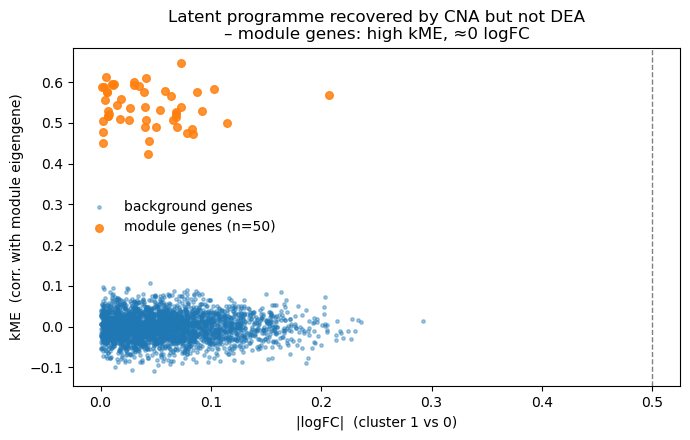

,abs_logFC,kME,is_module
0,0.016061,-0.012020,False
1,0.094571,0.011998,False
2,0.114144,-0.013889,False
3,0.023049,-0.025517,False
4,0.157564,-0.005853,False
...,...,...,...
2995,0.053312,0.002684,False
2996,0.102614,0.583936,True
2997,0.023585,0.010167,False
2998,0.012748,0.035485,False


In [6]:
run_simulation()

/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


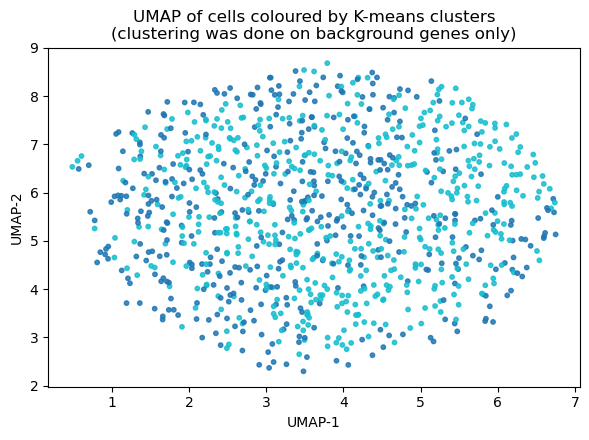

In [7]:
# ------------------------------------------------------------
# UMAP visualisation of the DEA-blind / CNA-visible simulation
# ------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# try UMAP (preferred); fall back to t-SNE if umap-learn isn’t installed
try:
    import umap
    DR = lambda x: umap.UMAP(n_neighbors=15, min_dist=0.3, random_state=42).fit_transform(x)
    dr_name = "UMAP"
except ImportError:
    from sklearn.manifold import TSNE
    DR = lambda x: TSNE(n_components=2, perplexity=30, init="pca", random_state=42).fit_transform(x)
    dr_name = "t-SNE"

# ---------- 1) simulate counts with a hidden correlated module ----------
N, G, M = 1_000, 3_000, 50
rng = np.random.default_rng(42)

counts = rng.negative_binomial(1, 0.2, size=(N, G)).astype(np.float32)

module_genes = rng.choice(G, M, replace=False)
z = rng.normal(0, 1, size=N)
for g in module_genes:
    counts[:, g] *= np.exp(rng.uniform(0.8, 1.2) * z)

log_counts = np.log1p(counts)

# ---------- 2) unsupervised clustering using *background* genes ----------
bg_idx = np.setdiff1d(np.arange(G), module_genes)
bg_scaled = StandardScaler().fit_transform(log_counts[:, bg_idx])

pcs = PCA(n_components=20, random_state=42).fit_transform(bg_scaled)
clusters = KMeans(n_clusters=2, n_init=10, random_state=42).fit_predict(pcs)

# ---------- 3) low-dim embedding + plot ----------
embedding = DR(pcs)

plt.figure(figsize=(6, 4.5))
plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=clusters,
    cmap="tab10",
    s=10,
    alpha=0.85,
    rasterized=True,
)
plt.xlabel(f"{dr_name}-1")
plt.ylabel(f"{dr_name}-2")
plt.title(f"{dr_name} of cells coloured by K-means clusters\n"
          "(clustering was done on background genes only)")
plt.tight_layout()
plt.show()
